# Custom Dataset：Kana (usb39 / semilearn 0.3.2)

本 Notebook 用于：
- 在 **usb39 (Python 3.10)** 环境中运行
- 使用你本地 editable 安装的 semilearn（`/root/autodl-tmp/Semi-supervised-learning`）
- 训练 Fixmatch_Shape_Consistency_Loss + ViT/Resnet50 on 自定义 Kana 数据集

⚠️ 如果你看到 semilearn 的路径指向 `/envs/usb/lib/python3.8/site-packages/...`，说明你选错 kernel（还是 usb/py38），会导致 `NotImplementedError`。

## 0) 环境与源码路径检查（必须通过）

In [1]:
import os, sys
import semilearn
from semilearn.core.utils import ALGORITHMS
import semilearn.algorithms.fixmatch_Shape_Consistency_Loss  # 确保触发注册
print('fixmatch_Shape_Consistency_Loss' in ALGORITHMS)


print('Python:', sys.version)
print('semilearn file:', semilearn.__file__)

# 强制确保你在 usb39 + 本地 repo 版本
expected_repo = '/root/autodl-tmp/Semi-supervised-learning'
if expected_repo not in semilearn.__file__:
    raise RuntimeError(
        "你现在的 kernel/环境不对：semilearn 不是从本地 repo 导入的。\n"
        f"当前：{semilearn.__file__}\n\n"
        "请在 Jupyter 右上角切换 Kernel 到：Python (usb39)，\n"
        "并确认你已在 usb39 环境里 `pip install -e /root/autodl-tmp/Semi-supervised-learning`。"
    )

print('✅ 环境检查通过：usb39 + 本地 semilearn 源码')

True
Python: 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
semilearn file: /root/autodl-tmp/Semi-supervised-learning/semilearn/__init__.py
✅ 环境检查通过：usb39 + 本地 semilearn 源码


## 1) 配置：Fixmatch_Shape_Consistency_Loss + ViT + Kana

- 数据目录：`/root/autodl-tmp/kana_raw_data_with_concentration_preprocessed_images`
- 3 类分类
- 标注数：12（每类 4 张）
- 小数据集：建议先缩短迭代验证全流程，然后再加大训练

⚠️ 注意：如果你用 ViT 预训练权重，必须确保路径存在；否则把 `use_pretrain=False`。

In [2]:
from semilearn import get_config
config_dict = {
    # algorithm / model
    'algorithm': 'fixmatch_Shape_Consistency_Loss',  # 确保使用正确的自定义算法名称
    'prior_lambda': 0.05,
    'proto_m': 0.95,
    'blue_k': 8,
    'blue_t': -0.040,
    'mask_tv_lambda': 0,
    'mask_iso_lambda': 0,
    'assume_imagenet_norm': True,
    'net': 'resnet50',
    'use_pretrain': False,
    # 'pretrain_path': '/root/.cache/torch/hub/checkpoints/vit_tiny_patch2_32_mlp_im_1k_32.pth',

    # dataset
    'dataset': 'kana',
    'data_dir': '/root/autodl-tmp/kana_circle_patches',
    'num_classes': 3,
    'num_labels': 3,  # 根据你实际标注样本数量调整（选取3/30/60，对应到每类有标签数量为1/10/20）
    'val_ratio': 0.2,  # 适当调整验证集占比
    'val_per_class': 3,

    # training schedule
    'epoch': 256,  # set to 100（这些是代码仓库对于cifar10的建议，卡那霉素就别这么大了）
    'num_train_iter': 500,  # set to 102400
    'num_eval_iter': 50,   # set to 1024
    'num_log_iter': 10,    # set to 256

    # optimizer
    'optim': 'AdamW',
    'lr': 1e-4,
    'layer_decay': 0.5,

    # batch
    'batch_size': 8,
    'eval_batch_size': 16,

    # Fixmatch_Shape_Consistency_Loss specific
    'hard_label': True,
    'uratio': 1,
    'p_cutoff': 0.95,
    'T': 0.5,
    'ulb_loss_ratio': 0.1,

    'ema_m': 0.999,

    'include_lb_to_ulb': True,

    # system
    'gpu': 0,
    'world_size': 1,
    'distributed': False,
    'num_workers': 2,

    # IMPORTANT
    'amp': False,
    'seed': 188997,
    
    #保存路径
    'save_dir':'./saved_results/kana_experiment',
    
    
    #禁用保存模型参数
    'save_model': False
}

import itertools

# 如果你没有预训练权重文件，就自动关掉
if config_dict.get('use_pretrain', False) and (not os.path.exists(config_dict['pretrain_path'])):
    print('⚠️ pretrain 权重不存在，自动改为 use_pretrain=False')
    config_dict['use_pretrain'] = False
    config_dict.pop('pretrain_path', None)

def make_save_name(cfg):
    label_num_per_class = cfg["num_labels"] / cfg["num_classes"]
    return (
        f'{cfg["algorithm"]}_{cfg["dataset"]}_{cfg["net"]}_labels{label_num_per_class}'
        f'_train{cfg["num_train_iter"]}_val{cfg["num_eval_iter"]}_test{cfg["num_eval_iter"]}'
        f'_classes{cfg["num_classes"]}_epoch{cfg["epoch"]}_lr{cfg["lr"]}_seed{cfg["seed"]}'
    )

def save_path_exists(cfg):
    save_name = make_save_name(cfg)
    return os.path.exists(os.path.join(cfg["save_dir"], save_name))

# 定义不同的变量值
num_labels_list = [3, 15, 30, 45]
seed_list = [0, 126, 2001, 2026, 159357, 654369, 650108, 528057, 20410, 188997]
net_list = ['resnet50', 'vit_tiny_patch2_32']
# 生成所有待跑组合（跳过已经存在的保存路径）
run_configs = []
for num_labels, seed, net in itertools.product(num_labels_list, seed_list, net_list):
    candidate = dict(config_dict)
    candidate["num_labels"] = num_labels
    candidate["seed"] = seed
    candidate["net"] = net
    candidate["save_name"] = make_save_name(candidate)
    if not save_path_exists(candidate):
        run_configs.append(candidate)

print(f"✅ 待运行组合数: {len(run_configs)}")


✅ 待运行组合数: 1


## 2) 构建 Algorithm（会自动构建 dataset + dataloader + optimizer）

如果这里能成功，说明：
- Kana dataset 已被正确注册 / 实现
- get_dataset 能跑通
- 你的 ViT timm 兼容修改生效

我们会把构建出来的 loader 取出来用于 Trainer。

In [3]:
from semilearn import get_algorithm, get_net_builder, Trainer

for i, cfg_dict in enumerate(run_configs, 1):
    cfg = get_config(cfg_dict)
    print(f"\n===== Run {i}/{len(run_configs)} =====")
    print(cfg.save_name)

    alg = get_algorithm(cfg, get_net_builder(cfg.net, from_name=False), tb_log=None, logger=None)
    print('✅ algorithm ok:', type(alg).__name__)

    loader_dict = getattr(alg, 'loader_dict', None)
    if loader_dict is None:
        raise RuntimeError('alg.loader_dict 不存在：你当前 semilearn 版本的接口可能不同')

    train_lb_loader = loader_dict.get('train_lb', None)
    train_ulb_loader = loader_dict.get('train_ulb', None)
    eval_loader = loader_dict.get('eval', None)
    assert train_lb_loader is not None and train_ulb_loader is not None and eval_loader is not None
    print('✅ loaders ready')

    # 下面接你的 Trainer / logger / fit 逻辑


===== Run 1/1 =====
fixmatch_Shape_Consistency_Loss_kana_vit_tiny_patch2_32_labels1.0_train500_val50_test50_classes3_epoch256_lr0.0001_seed654369
eval count: [3, 3, 3] (total=9)
train size: 210


/root/autodl-tmp/Semi-supervised-learning/semilearn/core/algorithmbase.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.loss_scaler = GradScaler()


lb count:  [1, 1, 1]
ulb count: [54, 12, 144]
unlabeled data number: 210, labeled data number 3
Create train and test data loaders
[!] data loader keys: dict_keys(['train_lb', 'train_ulb', 'eval'])
Create optimizer and scheduler
✅ algorithm ok: FixMatch_Shape_Consistency_Loss
✅ loaders ready


In [4]:
from collections import Counter

def get_targets(ds):
    for name in ['targets', 'labels', 'y']:
        if hasattr(ds, name):
            return list(getattr(ds, name))
    # 常见 torchvision ImageFolder 风格
    if hasattr(ds, 'samples'):
        return [y for _, y in ds.samples]
    if hasattr(ds, 'data') and hasattr(ds, 'targets'):
        return list(ds.targets)
    return None

ulb_ds = train_ulb_loader.dataset
lb_ds  = train_lb_loader.dataset
ev_ds  = eval_loader.dataset

for tag, ds in [('lb', lb_ds), ('ulb', ulb_ds), ('eval', ev_ds)]:
    t = get_targets(ds)
    if t is None:
        print(f'[{tag}] cannot find targets field, skip')
        continue
    c = Counter(t)
    print(f'[{tag}] size={len(t)}, dist={dict(sorted(c.items()))}')

# 强制：ulb 每类至少 1 张
t = get_targets(ulb_ds)
if t is not None:
    for k in range(cfg.num_classes):
        assert Counter(t).get(k, 0) > 0, f"❌ ULB class {k} is 0. Fix split first."
print("✅ split looks OK")

[lb] size=3, dist={np.int64(0): 1, np.int64(1): 1, np.int64(2): 1}
[ulb] size=210, dist={np.int64(0): 54, np.int64(1): 12, np.int64(2): 144}
[eval] size=9, dist={np.int64(0): 3, np.int64(1): 3, np.int64(2): 3}
✅ split looks OK


blue_score stats: min -0.06300000846385956 p1 -0.06300000846385956 p5 -0.06300000846385956 p50 -0.03616476058959961 p95 -0.0307511817663908 p99 -0.028909802436828613 max -0.025447070598602295


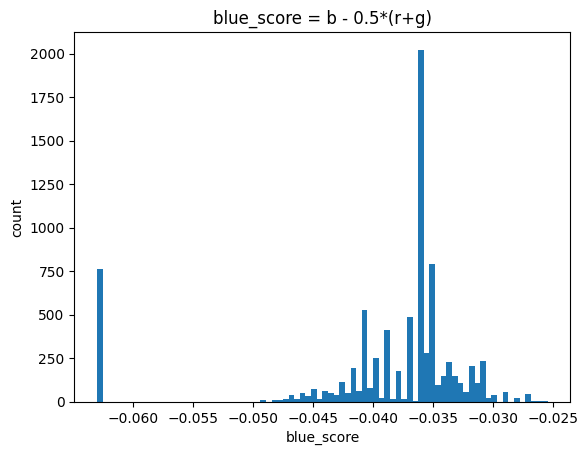

In [5]:
import torch
import matplotlib.pyplot as plt

assume_imagenet_norm = True
blue_k = 8.0

def denorm_if_needed(x, assume_imagenet_norm=True):
    if not assume_imagenet_norm:
        return x.clamp(0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
    x01 = x * std + mean
    return x01.clamp(0, 1)

@torch.no_grad()
def blue_score_map(x01):
    r = x01[:,0:1]
    g = x01[:,1:2]
    b = x01[:,2:3]
    return b - 0.5*(r+g)

def pick_first_image_tensor(batch):
    """
    从 semilearn loader 的 batch 里，挑出一个像 [B,3,H,W] 或 [3,H,W] 的 tensor。
    """
    # case 1: dict
    if isinstance(batch, dict):
        # 常见 key 优先级
        keys = ['x', 'image', 'img', 'x_lb', 'x_ulb_w', 'x_ulb_s']
        for k in keys:
            if k in batch and isinstance(batch[k], torch.Tensor):
                t = batch[k]
                if t.dim() in (3,4):
                    return t

        # 如果 key 不在上面列表里：遍历找第一个像图像的 tensor
        for k, v in batch.items():
            if isinstance(v, torch.Tensor) and v.dim() in (3,4):
                return v

        raise KeyError(f"batch 是 dict 但没找到图像 tensor，keys={list(batch.keys())}")

    # case 2: tuple/list
    if isinstance(batch, (list, tuple)):
        for v in batch:
            if isinstance(v, torch.Tensor) and v.dim() in (3,4):
                return v
        raise ValueError("batch 是 tuple/list 但没找到图像 tensor")

    # case 3: tensor
    if isinstance(batch, torch.Tensor):
        return batch

    raise TypeError(f"不支持的 batch 类型: {type(batch)}")

@torch.no_grad()
def collect_blue_scores(loader, max_batches=10, device='cuda'):
    vals = []
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break

        x = pick_first_image_tensor(batch)
        x = x.to(device)

        if x.dim() == 3:
            x = x.unsqueeze(0)  # [1,3,H,W]

        x01 = denorm_if_needed(x, assume_imagenet_norm=assume_imagenet_norm)
        s = blue_score_map(x01)  # [B,1,H,W]
        vals.append(s.flatten().detach().cpu())

    return torch.cat(vals, dim=0)

# 可视化阶段强制用 CPU，避免占用训练显存
device = 'cpu'
vals = collect_blue_scores(train_lb_loader, max_batches=5, device=device)

print("blue_score stats:",
      "min", float(vals.min()),
      "p1", float(torch.quantile(vals, 0.01)),
      "p5", float(torch.quantile(vals, 0.05)),
      "p50", float(torch.quantile(vals, 0.50)),
      "p95", float(torch.quantile(vals, 0.95)),
      "p99", float(torch.quantile(vals, 0.99)),
      "max", float(vals.max()))

plt.figure()
plt.hist(vals.numpy(), bins=80)
plt.title("blue_score = b - 0.5*(r+g)")
plt.xlabel("blue_score")
plt.ylabel("count")
plt.show()


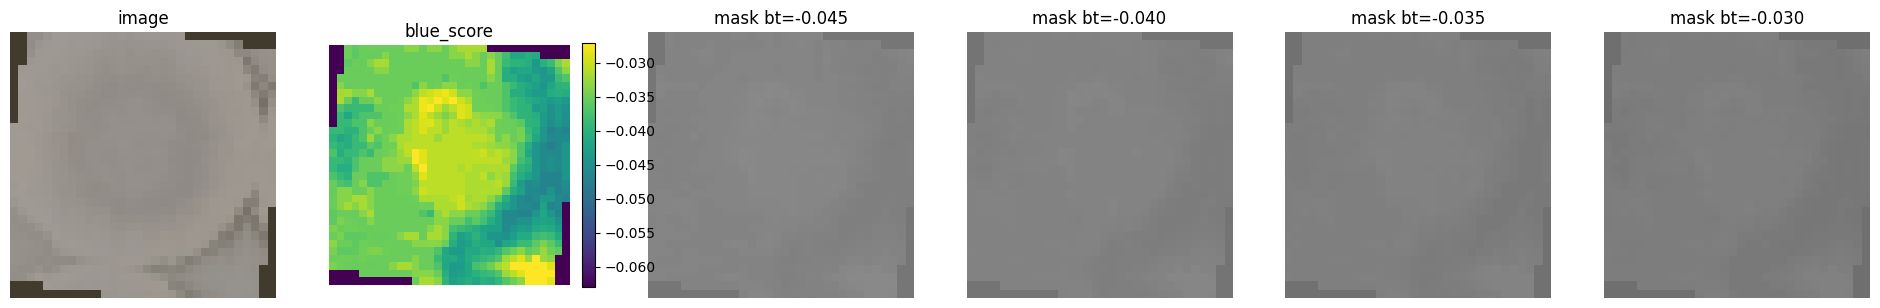

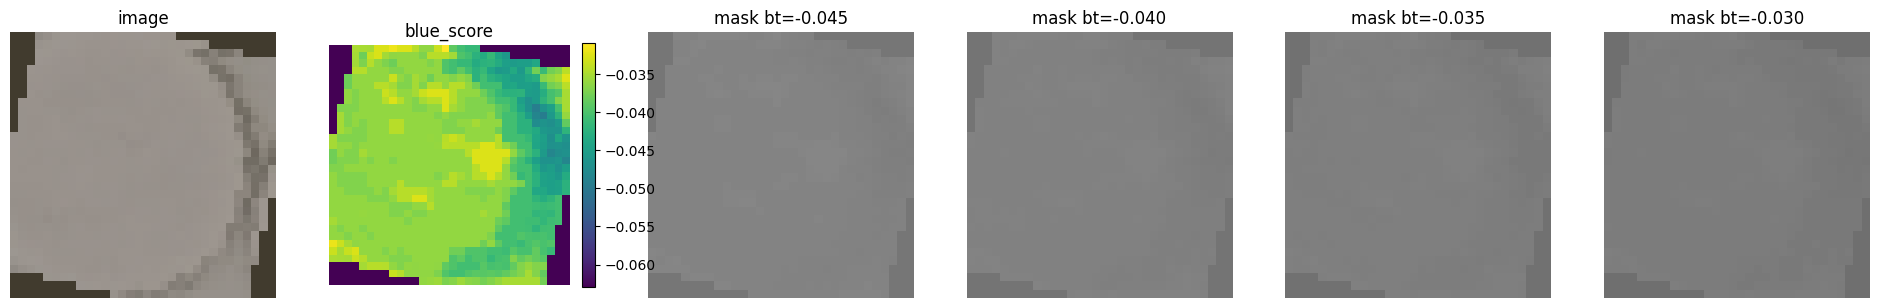

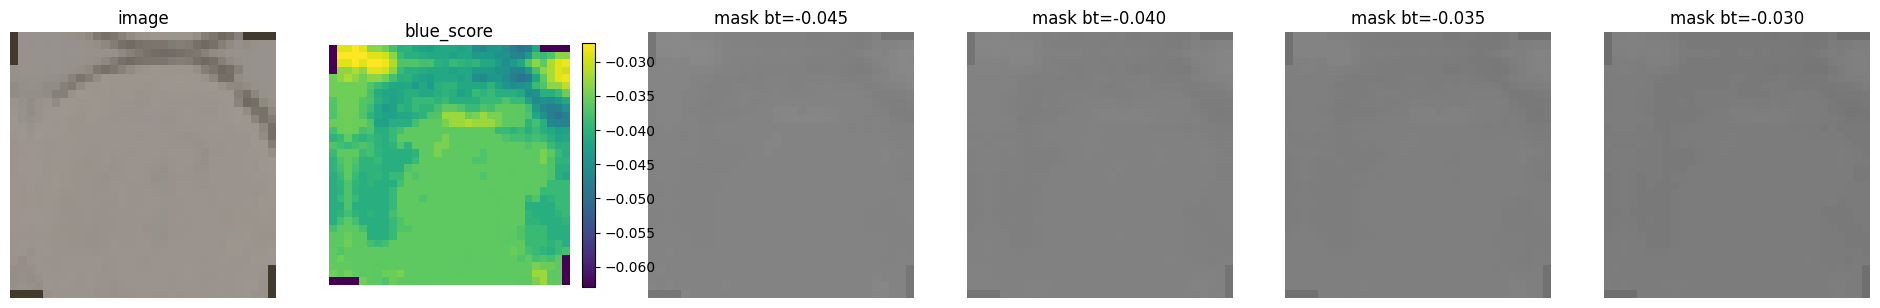

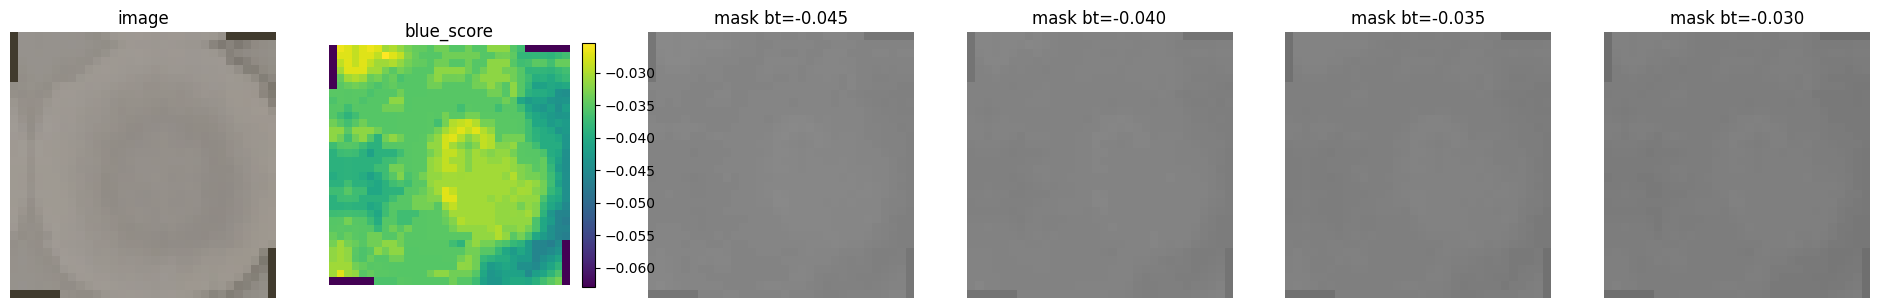

In [6]:
import torch
import matplotlib.pyplot as plt

assume_imagenet_norm = True
blue_k = 8.0

def denorm_if_needed(x, assume_imagenet_norm=True):
    if not assume_imagenet_norm:
        return x.clamp(0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
    return (x * std + mean).clamp(0, 1)

@torch.no_grad()
def blue_score_map(x01):
    r,g,b = x01[:,0:1], x01[:,1:2], x01[:,2:3]
    return b - 0.5*(r+g)  # [B,1,H,W]

def soft_mask_from_score(score, blue_k, blue_t):
    # 可微的“阈值化”
    return torch.sigmoid(blue_k * (score - blue_t))

def pick_first_image_tensor(batch):
    if isinstance(batch, dict):
        for k in ['x','image','img','x_lb','x_ulb_w','x_ulb_s']:
            if k in batch and isinstance(batch[k], torch.Tensor) and batch[k].dim() in (3,4):
                return batch[k]
        for _,v in batch.items():
            if isinstance(v, torch.Tensor) and v.dim() in (3,4):
                return v
        raise KeyError("dict batch里找不到图像tensor")
    if isinstance(batch, (list, tuple)):
        for v in batch:
            if isinstance(v, torch.Tensor) and v.dim() in (3,4):
                return v
        raise ValueError("tuple/list batch里找不到图像tensor")
    if isinstance(batch, torch.Tensor):
        return batch
    raise TypeError(type(batch))

@torch.no_grad()
def visualize_masks(loader, blue_t_list, n_show=4, device='cpu'):
    batch = next(iter(loader))
    x = pick_first_image_tensor(batch).to(device)
    if x.dim() == 3:
        x = x.unsqueeze(0)
    x = x[:n_show]

    x01 = denorm_if_needed(x, assume_imagenet_norm)
    score = blue_score_map(x01)  # [B,1,H,W]

    for i in range(x01.size(0)):
        img = x01[i].permute(1,2,0).cpu()
        sc  = score[i,0].cpu()

        fig, axes = plt.subplots(1, 2 + len(blue_t_list), figsize=(4*(2+len(blue_t_list)), 4))
        axes[0].imshow(img); axes[0].set_title("image"); axes[0].axis("off")
        im1 = axes[1].imshow(sc, cmap='viridis'); axes[1].set_title("blue_score"); axes[1].axis("off")
        plt.colorbar(im1, ax=axes[1], fraction=0.046)

        for j, bt in enumerate(blue_t_list):
            m = soft_mask_from_score(score[i:i+1], blue_k, bt)[0,0].cpu()
            axes[2+j].imshow(m, cmap='gray', vmin=0, vmax=1)
            axes[2+j].set_title(f"mask bt={bt:.3f}")
            axes[2+j].axis("off")

        plt.show()

device = 'cpu'  # 可视化阶段强制 CPU，避免 OOM
blue_t_list = [-0.045, -0.040, -0.035, -0.030]
visualize_masks(train_lb_loader, blue_t_list, n_show=4, device=device)


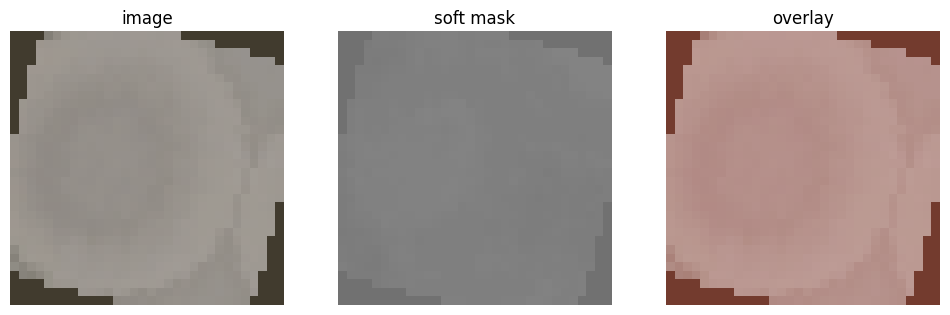

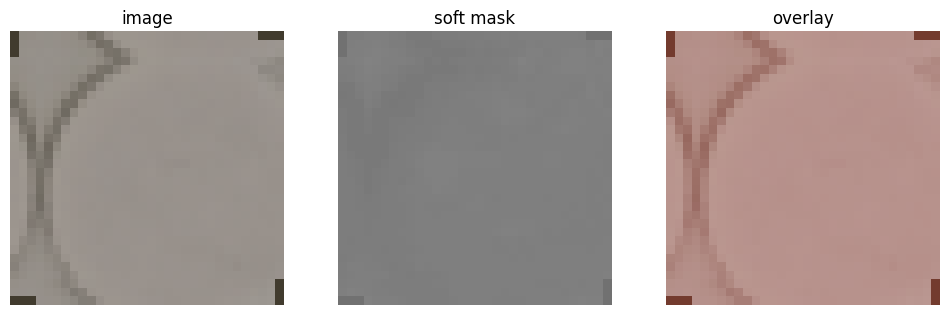

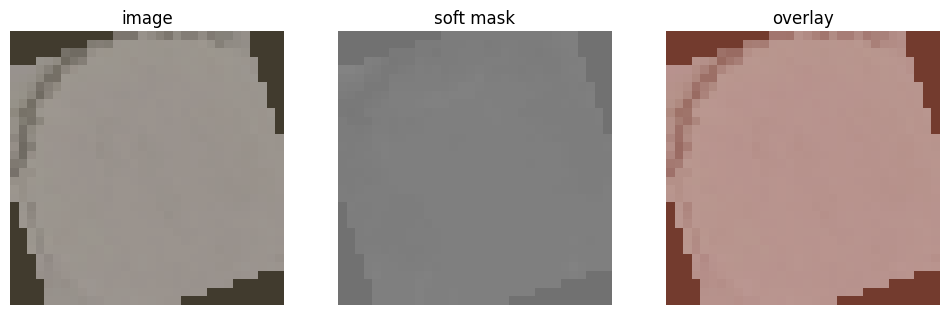

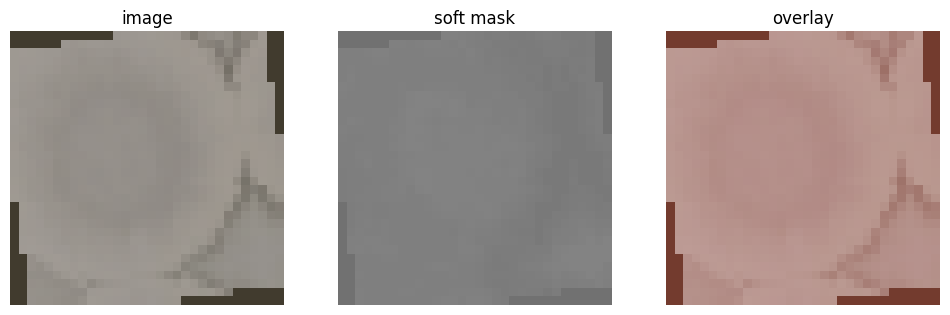

In [9]:
import torch
import matplotlib.pyplot as plt

blue_k = 8.0
blue_t = -0.035
assume_imagenet_norm = True

def denorm_if_needed(x, assume_imagenet_norm=True):
    if not assume_imagenet_norm:
        return x.clamp(0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
    return (x * std + mean).clamp(0, 1)

@torch.no_grad()
def blue_score_map(x01):
    r,g,b = x01[:,0:1], x01[:,1:2], x01[:,2:3]
    return b - 0.5*(r+g)

def soft_mask(score, blue_k, blue_t):
    return torch.sigmoid(blue_k * (score - blue_t))  # [B,1,H,W]

def pick_first_image_tensor(batch):
    if isinstance(batch, dict):
        for k in ['x','image','img','x_lb','x_ulb_w','x_ulb_s']:
            if k in batch and isinstance(batch[k], torch.Tensor):
                return batch[k]
        for v in batch.values():
            if isinstance(v, torch.Tensor):
                return v
    elif isinstance(batch, (list, tuple)):
        for v in batch:
            if isinstance(v, torch.Tensor):
                return v
    return batch

device = 'cpu'  # 可视化用 CPU，避免显存占用
batch = next(iter(train_lb_loader))
x = pick_first_image_tensor(batch).to(device)
if x.dim() == 3: x = x.unsqueeze(0)

x01 = denorm_if_needed(x[:4], assume_imagenet_norm)
score = blue_score_map(x01)
m = soft_mask(score, blue_k, blue_t)  # [B,1,H,W]

for i in range(x01.size(0)):
    img = x01[i].permute(1,2,0).cpu()
    mask = m[i,0].cpu()

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(mask, cmap='gray', vmin=0, vmax=1); plt.title("soft mask"); plt.axis("off")

    # overlay（红色高亮 mask）
    overlay = img.clone()
    overlay[...,0] = (overlay[...,0] * (1-0.6*mask) + 0.6*mask).clamp(0,1)  # 红通道增强
    plt.subplot(1,3,3); plt.imshow(overlay); plt.title("overlay"); plt.axis("off")
    plt.show()


In [10]:
#在此notebook中以上内容仅仅是可视化，没有实际运用进train的过程

## 3) 训练与评估（兼容不同 Trainer.fit 签名）

不同 semilearn 版本里 `Trainer.fit()` 有两种常见签名：
- `trainer.fit()` （Trainer 自己去拿 alg 内部 loader）
- `trainer.fit(train_lb_loader, train_ulb_loader, eval_loader)`

下面写法会自动兼容。

In [11]:
from semilearn import Trainer, get_algorithm, get_net_builder
import os, logging, gc, torch

for i, cfg_dict in enumerate(run_configs, 1):
    cfg = get_config(cfg_dict)
    print(f"\n===== Run {i}/{len(run_configs)} =====")
    print(cfg.save_name)

    alg = get_algorithm(cfg, get_net_builder(cfg.net, from_name=False), tb_log=None, logger=None)

    # logger: 每个实验各自一个 log 文件
    log_dir = os.path.join(cfg.save_dir, cfg.save_name)
    os.makedirs(log_dir, exist_ok=True)
    logger = logging.getLogger(f"train_{cfg.save_name}")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    logger.addHandler(logging.FileHandler(os.path.join(log_dir, "train.log")))
    logger.addHandler(logging.StreamHandler())

    if hasattr(alg, "logger"):
        alg.logger = logger

    trainer = Trainer(cfg, alg)
    if hasattr(trainer, "logger"):
        trainer.logger = logger

    # 禁止保存 pth（你已加 save_model=False，这里再保险）
    def _noop(*args, **kwargs):
        return None
    if hasattr(trainer, "save_model"):
        trainer.save_model = _noop
    if hasattr(trainer, "save_checkpoint"):
        trainer.save_checkpoint = _noop

    # 训练
    try:
        trainer.fit()
    except TypeError:
        loader_dict = getattr(alg, 'loader_dict', None)
        trainer.fit(loader_dict['train_lb'], loader_dict['train_ulb'], loader_dict['eval'])

    # 评估
    try:
        out = trainer.evaluate(alg.loader_dict['eval'])
        print('evaluate output:', out)
    except Exception as e:
        print('trainer.evaluate(eval_loader) failed:', repr(e))

    # 释放显存，避免长循环 OOM
    del trainer, alg
    gc.collect()
    torch.cuda.empty_cache()



===== Run 1/1 =====
fixmatch_Shape_Consistency_Loss_kana_vit_tiny_patch2_32_labels1.0_train500_val50_test50_classes3_epoch256_lr0.0001_seed654369
eval count: [3, 3, 3] (total=9)
train size: 210
lb count:  [1, 1, 1]
ulb count: [54, 12, 144]
unlabeled data number: 210, labeled data number 3
Create train and test data loaders
[!] data loader keys: dict_keys(['train_lb', 'train_ulb', 'eval'])
Create optimizer and scheduler


/root/autodl-tmp/Semi-supervised-learning/semilearn/core/algorithmbase.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.loss_scaler = GradScaler()


Epoch: 0


Iter 0: train/sup_loss: 1.2047 | train/unsup_loss: 0.0000 | train/prior_loss: 0.0000 | train/total_loss: 1.2047 | train/util_ratio: 0.0000 | train/proto_cnt_min: 2.0000 | train/proto_cnt_max: 3.0000 | train/proto_cnt_sum: 8.0000
[2026-02-28 18:20:57,771 INFO] Iter 0: train/sup_loss: 1.2047 | train/unsup_loss: 0.0000 | train/prior_loss: 0.0000 | train/total_loss: 1.2047 | train/util_ratio: 0.0000 | train/proto_cnt_min: 2.0000 | train/proto_cnt_max: 3.0000 | train/proto_cnt_sum: 8.0000
/root/miniconda3/envs/usb39/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
confusion matrix
[2026-02-28 18:20:57,907 INFO] confusion matrix
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
[2026-02-28 18:20:57,910 INFO] [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
eva

Epoch: 1


...

Epoch: 254


/root/miniconda3/envs/usb39/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
confusion matrix
[2026-02-28 18:22:18,233 INFO] confusion matrix
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
[2026-02-28 18:22:18,236 INFO] [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
evaluation metric
[2026-02-28 18:22:18,239 INFO] evaluation metric
acc: 0.3333
[2026-02-28 18:22:18,240 INFO] acc: 0.3333
precision: 0.1111
[2026-02-28 18:22:18,242 INFO] precision: 0.1111
recall: 0.3333
[2026-02-28 18:22:18,243 INFO] recall: 0.3333
f1: 0.1667
[2026-02-28 18:22:18,245 INFO] f1: 0.1667


Epoch: 255


/root/miniconda3/envs/usb39/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
confusion matrix
[2026-02-28 18:22:18,570 INFO] confusion matrix
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
[2026-02-28 18:22:18,572 INFO] [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
evaluation metric
[2026-02-28 18:22:18,575 INFO] evaluation metric
acc: 0.3333
[2026-02-28 18:22:18,576 INFO] acc: 0.3333
precision: 0.1111
[2026-02-28 18:22:18,578 INFO] precision: 0.1111
recall: 0.3333
[2026-02-28 18:22:18,579 INFO] recall: 0.3333
f1: 0.1667
[2026-02-28 18:22:18,581 INFO] f1: 0.1667
Best acc 0.0000 at epoch 0
[2026-02-28 18:22:18,582 INFO] Best acc 0.0000 at epoch 0
Training finished.
[2026-02-28 18:22:18,584 INFO] Training finished.
/root/miniconda3/envs/usb39/lib/pyt

evaluate output: {'acc': 0.3333333333333333, 'precision': 0.1111111111111111, 'recall': 0.3333333333333333, 'f1': 0.16666666666666666}


## 4) 正式训练（把 iter/epoch 拉大）

当上面 2 epoch / 50 iter 能跑通后，再把这里的参数加大，例如：
- `epoch=20`
- `num_train_iter=2000`
- `num_eval_iter=200`

同时小数据集建议：
- `p_cutoff` 可以试试 0.7~0.95
- `uratio` 先用 1~2
- 如果过拟合很快，减小 lr 或增加 weight decay/数据增强